In [37]:
from insightface.app import FaceAnalysis
from insightface.data import get_image as ins_get_image
from insightface.utils import face_align
import json
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import PIL
from PIL import Image
import scipy
%matplotlib inline

In [2]:

app = FaceAnalysis(name='buffalo_l')
app.prepare(ctx_id=0, det_size=(640, 640))

Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
find model: /home/a.nugroho/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPU

In [25]:
source_dir = "/mnt/ssd/workspace/adi/repos/vh_deepfake_trainer/datasets/deepfake/200k_live_face_dataset/live"
source_path = os.path.join(source_dir,os.listdir(source_dir)[0])

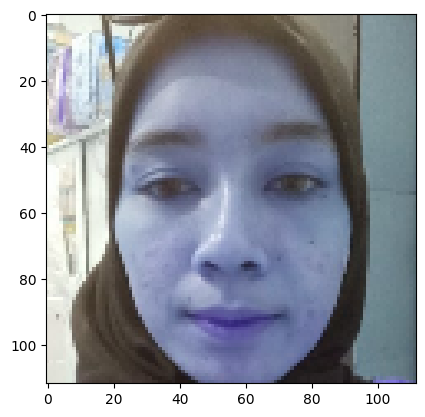

In [26]:
img = cv2.imread(source_path)
faces = app.get(img)
source_face = faces[0]
source_img_face = face_align.norm_crop(img,source_face.kps)
plt.imshow(source_img_face)

In [29]:
source_face.landmark_3d_68

array([[ 1.64495911e+02,  2.31035095e+02,  1.59166992e+02],
       [ 1.71827637e+02,  2.64388519e+02,  1.56727173e+02],
       [ 1.79559296e+02,  2.97247467e+02,  1.52311172e+02],
       [ 1.87158722e+02,  3.27774323e+02,  1.43617462e+02],
       [ 1.97515533e+02,  3.55126953e+02,  1.21699936e+02],
       [ 2.10427124e+02,  3.76505066e+02,  1.01691956e+02],
       [ 2.26088211e+02,  3.93739410e+02,  8.37662659e+01],
       [ 2.46874786e+02,  4.08062195e+02,  6.09116898e+01],
       [ 2.80202545e+02,  4.18197540e+02,  5.07872543e+01],
       [ 3.12339508e+02,  4.09182220e+02,  6.21904984e+01],
       [ 3.37492249e+02,  3.91960938e+02,  8.51911545e+01],
       [ 3.54763031e+02,  3.70095032e+02,  1.08112755e+02],
       [ 3.65888702e+02,  3.50484436e+02,  1.30114395e+02],
       [ 3.73339050e+02,  3.28897461e+02,  1.47881683e+02],
       [ 3.80516693e+02,  2.97631683e+02,  1.59332886e+02],
       [ 3.85861786e+02,  2.61198181e+02,  1.58062607e+02],
       [ 3.92631805e+02,  2.30105103e+02

In [36]:
# Need 68-p landmark detector
#landmarks_detector = face_alignment.FaceAlignment(face_alignment.LandmarksType._3D, flip_input=False)

In [40]:
def image_align(src_file, face_landmarks, output_size=256, transform_size=1024, enable_padding=True):
        # Align function from FFHQ dataset pre-processing step
        # https://github.com/NVlabs/ffhq-dataset/blob/master/download_ffhq.py

        lm = np.array(face_landmarks)
        lm_chin          = lm[0  : 17, :2]  # left-right
        lm_eyebrow_left  = lm[17 : 22, :2]  # left-right
        lm_eyebrow_right = lm[22 : 27, :2]  # left-right
        lm_nose          = lm[27 : 31, :2]  # top-down
        lm_nostrils      = lm[31 : 36, :2]  # top-down
        lm_eye_left      = lm[36 : 42, :2]  # left-clockwise
        lm_eye_right     = lm[42 : 48, :2]  # left-clockwise
        lm_mouth_outer   = lm[48 : 60, :2]  # left-clockwise
        lm_mouth_inner   = lm[60 : 68, :2]  # left-clockwise

        # Calculate auxiliary vectors.
        eye_left     = np.mean(lm_eye_left, axis=0)
        eye_right    = np.mean(lm_eye_right, axis=0)
        eye_avg      = (eye_left + eye_right) * 0.5
        eye_to_eye   = eye_right - eye_left
        mouth_left   = lm_mouth_outer[0]
        mouth_right  = lm_mouth_outer[6]
        mouth_avg    = (mouth_left + mouth_right) * 0.5
        eye_to_mouth = mouth_avg - eye_avg

        # Choose oriented crop rectangle.
        x = eye_to_eye - np.flipud(eye_to_mouth) * [-1, 1]
        x /= np.hypot(*x)
        x *= max(np.hypot(*eye_to_eye) * 2.0, np.hypot(*eye_to_mouth) * 1.8)
        y = np.flipud(x) * [-1, 1]
        c = eye_avg + eye_to_mouth * 0.1
        quad = np.stack([c - x - y, c - x + y, c + x + y, c + x - y])
        qsize = np.hypot(*x) * 2

        # Load in-the-wild image.
        if not os.path.isfile(src_file):
            print('\nCannot find source image. Please run "--wilds" before "--align".')
            return
        img = Image.open(src_file)

        # Shrink.
        shrink = int(np.floor(qsize / output_size * 0.5))
        if shrink > 1:
            rsize = (int(np.rint(float(img.size[0]) / shrink)), int(np.rint(float(img.size[1]) / shrink)))
            #img = img.resize(rsize, Image.ANTIALIAS)
            img = img.resize(rsize)
            quad /= shrink
            qsize /= shrink

        # Crop.
        border = max(int(np.rint(qsize * 0.1)), 3)
        crop = (int(np.floor(min(quad[:,0]))), int(np.floor(min(quad[:,1]))), int(np.ceil(max(quad[:,0]))), int(np.ceil(max(quad[:,1]))))
        crop = (max(crop[0] - border, 0), max(crop[1] - border, 0), min(crop[2] + border, img.size[0]), min(crop[3] + border, img.size[1]))
        if crop[2] - crop[0] < img.size[0] or crop[3] - crop[1] < img.size[1]:
            img = img.crop(crop)
            quad -= crop[0:2]

        # Pad.
        pad = (int(np.floor(min(quad[:,0]))), int(np.floor(min(quad[:,1]))), int(np.ceil(max(quad[:,0]))), int(np.ceil(max(quad[:,1]))))
        pad = (max(-pad[0] + border, 0), max(-pad[1] + border, 0), max(pad[2] - img.size[0] + border, 0), max(pad[3] - img.size[1] + border, 0))
        if enable_padding and max(pad) > border - 4:
            pad = np.maximum(pad, int(np.rint(qsize * 0.3)))
            img = np.pad(np.float32(img), ((pad[1], pad[3]), (pad[0], pad[2]), (0, 0)), 'reflect')
            h, w, _ = img.shape
            y, x, _ = np.ogrid[:h, :w, :1]
            mask = np.maximum(1.0 - np.minimum(np.float32(x) / pad[0], np.float32(w-1-x) / pad[2]), 1.0 - np.minimum(np.float32(y) / pad[1], np.float32(h-1-y) / pad[3]))
            blur = qsize * 0.02
            img += (scipy.ndimage.gaussian_filter(img, [blur, blur, 0]) - img) * np.clip(mask * 3.0 + 1.0, 0.0, 1.0)
            img += (np.median(img, axis=(0,1)) - img) * np.clip(mask, 0.0, 1.0)
            img = Image.fromarray(np.uint8(np.clip(np.rint(img), 0, 255)), 'RGB')
            quad += pad[:2]

        # Transform.
        img = img.transform((transform_size, transform_size), Image.Transform.QUAD, (quad + 0.5).flatten(), Image.Resampling.BILINEAR)
        if output_size < transform_size:
            img = img.resize((output_size, output_size))

        # Save aligned image.
        #img.save(dst_file, 'PNG')
        return img


In [60]:
source_dir = "/mnt/ssd/workspace/adi/repos/vh_deepfake_trainer/datasets/deepfake/200k_live_face_dataset/live"
target_path = os.path.join(source_dir,os.listdir(source_dir)[4])
img = cv2.imread(target_path)
faces = app.get(img)
source_face = faces[0]

In [61]:
aligned = image_align(target_path, source_face.landmark_3d_68, output_size=256, transform_size=1024, enable_padding=True)

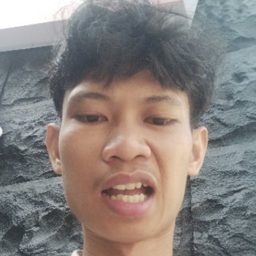

In [62]:
aligned